# 🛒 Prévision des Ventes Hebdomadaires Walmart — Pipeline Complet

Ce notebook suit le pipeline standard et professionnel d'un projet de série temporelle, de bout en bout.

**Dataset :** Walmart Sales — ventes hebdomadaires de plusieurs magasins  
**Objectif :** Prévoir les ventes hebdomadaires futures  
**Modèle principal :** SARIMAX avec variables exogènes

---

## 📋 Plan du notebook
1. Imports & Configuration
2. Chargement des données
3. Nettoyage & Préparation
4. Analyse Exploratoire (EDA)
5. Décomposition de la série
6. Test de stationnarité (ADF + KPSS)
7. Analyse ACF / PACF
8. Modèle Baseline (référence)
9. Sélection automatique des paramètres (auto_arima)
10. Entraînement SARIMAX
11. Diagnostic des résidus
12. Évaluation sur le test set (avec comparaison baseline)
13. Cross-Validation temporelle
14. Forecast final
15. Conclusion & Interprétation métier

---
> **▶️ Utilisation** — Ce notebook est livré **déjà exécuté** (tous les résultats sont visibles).  
> Pour le relancer : placer `Walmart_Sales.csv` dans le même dossier puis *Run All* (compatible Jupyter local et Google Colab).  
> Une application **Streamlit** (`app.py`) accompagne ce notebook pour explorer les prévisions de façon interactive.

---
## 📦 1. Imports & Configuration

In [1]:
# ====================================================
# 📦 IMPORTS
# ====================================================

import sys, subprocess, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# --- Statistiques & Tests ---
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import scipy.stats as stats

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)   # statsmodels réactive ce warning à l'import

# --- Métriques ---
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# --- Auto-sélection SARIMA (installation uniquement si absent) ---
try:
    from pmdarima import auto_arima
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pmdarima', '-q'])
    from pmdarima import auto_arima

# ====================================================
# ⚙️ CONFIGURATION GLOBALE
# ====================================================

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Seed pour reproductibilité
np.random.seed(42)

print('✅ Imports et configuration OK')

✅ Imports et configuration OK


---
## 📥 2. Chargement des données

In [2]:
# ====================================================
# 📥 CHARGEMENT
# ====================================================

# On charge le dataset complet ici (avec toutes les colonnes)
# car on va utiliser les variables exogènes plus tard

# Sur Google Colab : on demande l'upload si le fichier n'est pas déjà là
# En local (Jupyter) : le fichier Walmart_Sales.csv doit être dans le dossier du notebook
if 'google.colab' in sys.modules and not os.path.exists('Walmart_Sales.csv'):
    from google.colab import files
    files.upload()

print('Fichier trouvé :', os.path.exists('Walmart_Sales.csv'))

Fichier trouvé : True


In [3]:
df_raw = pd.read_csv("Walmart_Sales.csv")

print(f"Dimensions : {df_raw.shape}")
print(f"Colonnes   : {list(df_raw.columns)}")
df_raw.head(10)

Dimensions : (6435, 8)
Colonnes   : ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


In [4]:
# Aperçu statistique général
df_raw.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [5]:
# Types de données
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 465.2 KB


---
## 🧹 3. Nettoyage & Préparation

In [6]:
# ====================================================
# 🗓️ CONVERSION DE LA DATE
# ====================================================

# Le format est jour/mois/année dans ce dataset
# errors='coerce' : les dates invalides deviennent NaN (au lieu de planter)
df_raw['Date'] = pd.to_datetime(df_raw['Date'], dayfirst=True, errors='coerce')

# On supprime les lignes où la date est illisible
df_raw = df_raw.dropna(subset=['Date'])

print(f"Plage temporelle : {df_raw['Date'].min()} → {df_raw['Date'].max()}")
print(f"Nombre de dates uniques : {df_raw['Date'].nunique()}")

Plage temporelle : 2010-02-05 00:00:00 → 2012-10-26 00:00:00
Nombre de dates uniques : 143


In [7]:
# ====================================================
# 🏪 AGRÉGATION MULTI-MAGASINS
# ====================================================

# Le dataset contient plusieurs magasins (Store) pour la même date
# On construit deux versions :
#   - df       : série principale (Weekly_Sales agrégé)
#   - df_exog  : variables exogènes moyennées par date

# Colonnes exogènes disponibles
# (on vérifie d'abord si elles existent dans le dataset)
exog_cols = [c for c in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag'] 
             if c in df_raw.columns]

print(f"Variables exogènes disponibles : {exog_cols}")

# Agrégation des ventes : somme (ventes totales de tous les magasins)
df_sales = df_raw.groupby('Date')['Weekly_Sales'].sum().rename('Weekly_Sales')

# Agrégation des exogènes : moyenne (représentatif du contexte global)
if exog_cols:
    df_exog = df_raw.groupby('Date')[exog_cols].mean()
    df = pd.concat([df_sales, df_exog], axis=1)
else:
    df = df_sales.to_frame()

print(f"\nShape après agrégation : {df.shape}")
df.head()

Variables exogènes disponibles : ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']

Shape après agrégation : (143, 6)


,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Holiday_Flag
Date,,,,,,
2010-02-05,49750740.50,34.037333,2.717844,167.730885,8.619311,0.0
2010-02-12,48336677.63,34.151333,2.694022,167.825608,8.619311,1.0
2010-02-19,48276993.78,37.719778,2.672067,167.871686,8.619311,0.0
2010-02-26,43968571.13,39.243556,2.683933,167.909657,8.619311,0.0
2010-03-05,46871470.30,42.917333,2.731200,167.947628,8.619311,0.0


In [8]:
# ====================================================
# 📆 FRÉQUENCE FIXE
# ====================================================

# Pour les séries temporelles, la fréquence doit être strictement régulière
# Le dataset Walmart est hebdomadaire, aligné sur le vendredi (W-FRI)
df = df.asfreq('W-FRI')

# Vérification des valeurs manquantes après passage en fréquence fixe
print("Valeurs manquantes avant remplissage :")
print(df.isnull().sum())

Valeurs manquantes avant remplissage :
Weekly_Sales    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Holiday_Flag    0
dtype: int64


In [9]:
# ====================================================
# 🔧 TRAITEMENT DES VALEURS MANQUANTES
# ====================================================

# On utilise l'interpolation linéaire en priorité (plus réaliste que ffill)
# puis ffill/bfill pour combler les extrémités
df = df.interpolate(method='linear').ffill().bfill()

print("Valeurs manquantes après remplissage :")
print(df.isnull().sum())

Valeurs manquantes après remplissage :
Weekly_Sales    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Holiday_Flag    0
dtype: int64


Borne inférieure : 36,146,276
Borne supérieure : 56,526,336
Nombre d'outliers détectés : 6


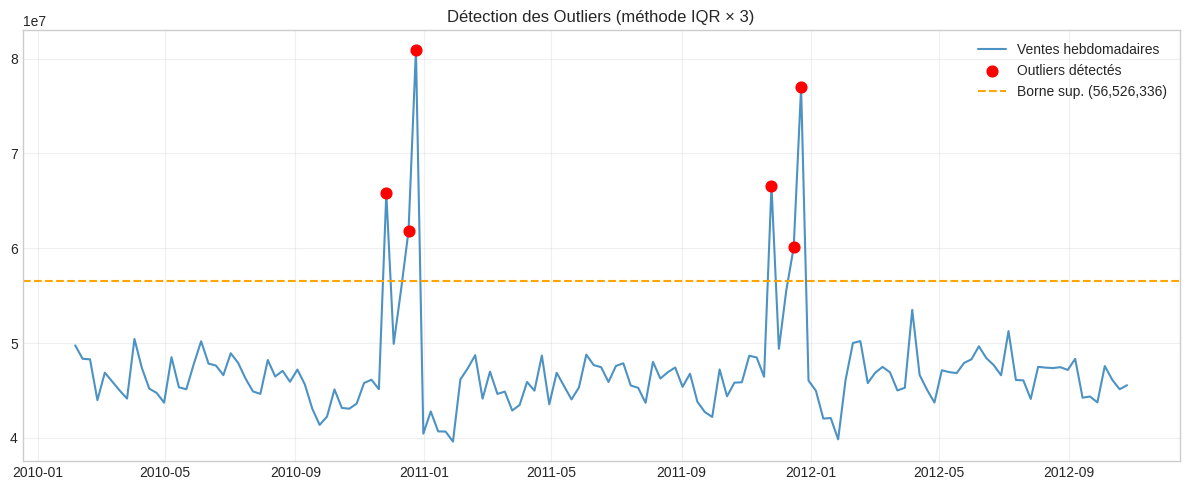

In [10]:
# ====================================================
# 🚨 DÉTECTION DES OUTLIERS (IQR Method)
# ====================================================

# Les outliers (pics de ventes : Black Friday, Noël, etc.) peuvent biaiser le modèle
# On les identifie d'abord, puis on choisit de les garder ou les remplacer

Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR   # 3x IQR = seuil conservateur (on garde les pics saisonniers normaux)
upper_bound = Q3 + 3 * IQR

outliers = df['Weekly_Sales'][(df['Weekly_Sales'] < lower_bound) | (df['Weekly_Sales'] > upper_bound)]

print(f"Borne inférieure : {lower_bound:,.0f}")
print(f"Borne supérieure : {upper_bound:,.0f}")
print(f"Nombre d'outliers détectés : {len(outliers)}")

# Visualisation des outliers sur la série
plt.figure(figsize=(12, 5))
plt.plot(df['Weekly_Sales'], label='Ventes hebdomadaires', alpha=0.8)
plt.scatter(outliers.index, outliers.values, color='red', zorder=5, label='Outliers détectés', s=60)
plt.axhline(upper_bound, linestyle='--', color='orange', label=f'Borne sup. ({upper_bound:,.0f})')
plt.title("Détection des Outliers (méthode IQR × 3)")
plt.legend()
plt.tight_layout()
plt.show()

# ⚠️ On décide de garder les outliers ici car ils correspondent à de vraies périodes
# (fêtes, promotions Walmart) — les remplacer fausserait la saisonnalité

---
## 🔎 4. Analyse Exploratoire (EDA)

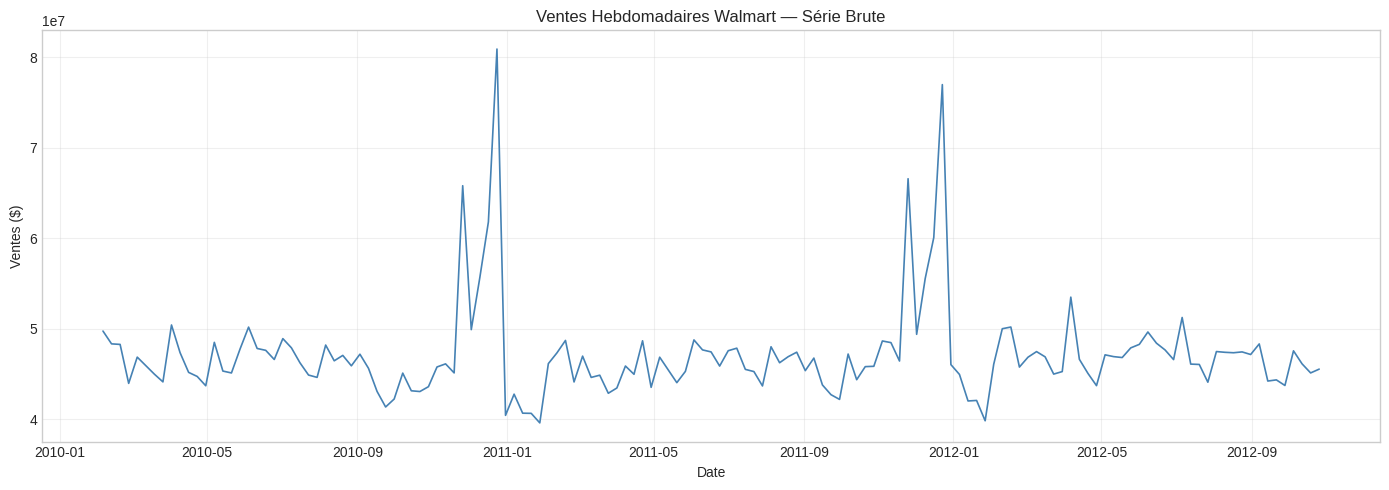

In [11]:
# ====================================================
# 📈 VISUALISATION DE LA SÉRIE BRUTE
# ====================================================

plt.figure(figsize=(14, 5))
plt.plot(df['Weekly_Sales'], color='steelblue', linewidth=1.2)
plt.title("Ventes Hebdomadaires Walmart — Série Brute")
plt.xlabel("Date")
plt.ylabel("Ventes ($)")
plt.tight_layout()
plt.show()

# Ce qu'on observe :
# - Saisonnalité annuelle visible (pics récurrents en fin d'année)
# - Tendance légèrement croissante ou stable
# - Quelques pics importants = périodes de fêtes

In [12]:
# ====================================================
# 📊 STATISTIQUES DESCRIPTIVES
# ====================================================

print("=" * 50)
print("STATISTIQUES DE LA VARIABLE CIBLE")
print("=" * 50)

stats_desc = df['Weekly_Sales'].describe()
print(stats_desc)
print(f"\nSkewness   : {df['Weekly_Sales'].skew():.3f}  (0 = symétrique, >0 = queue à droite)")
print(f"Kurtosis   : {df['Weekly_Sales'].kurtosis():.3f}  (3 = normale, >3 = queues épaisses)")
print(f"Coefficient de variation : {(df['Weekly_Sales'].std() / df['Weekly_Sales'].mean() * 100):.1f}%")

STATISTIQUES DE LA VARIABLE CIBLE
count    1.430000e+02
mean     4.711342e+07
std      5.444206e+06
min      3.959985e+07
25%      4.488059e+07
50%      4.624390e+07
75%      4.779202e+07
max      8.093142e+07
Name: Weekly_Sales, dtype: float64

Skewness   : 3.671  (0 = symétrique, >0 = queue à droite)
Kurtosis   : 17.668  (3 = normale, >3 = queues épaisses)
Coefficient de variation : 11.6%


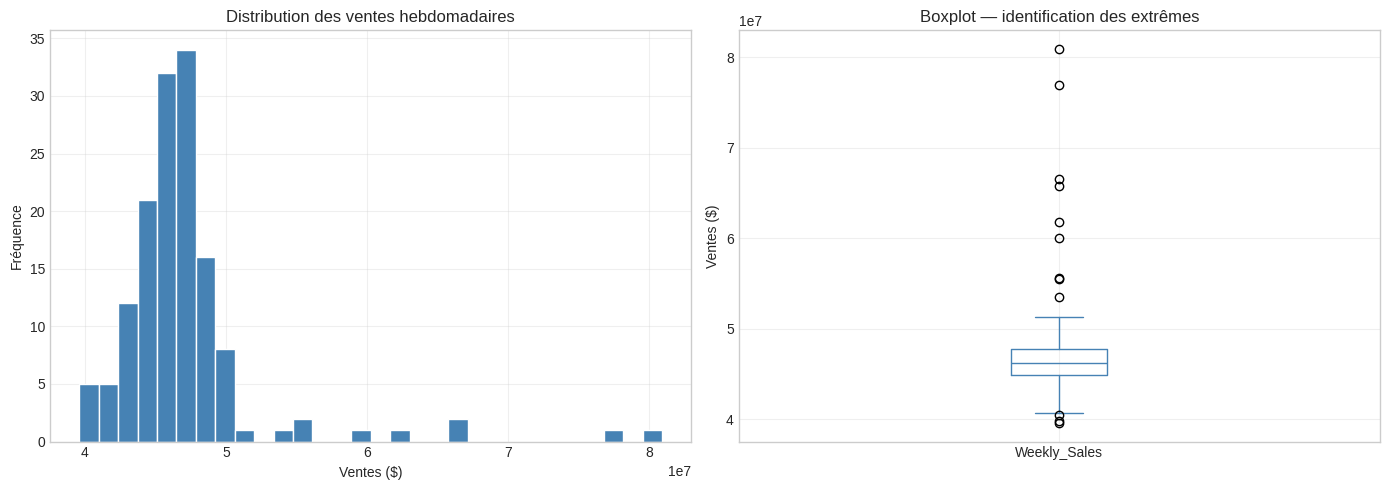

In [13]:
# ====================================================
# 📉 DISTRIBUTION + BOXPLOT
# ====================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme avec courbe KDE
df['Weekly_Sales'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Distribution des ventes hebdomadaires")
axes[0].set_xlabel("Ventes ($)")
axes[0].set_ylabel("Fréquence")

# Boxplot pour voir les outliers
df['Weekly_Sales'].plot.box(ax=axes[1], color='steelblue')
axes[1].set_title("Boxplot — identification des extrêmes")
axes[1].set_ylabel("Ventes ($)")

plt.tight_layout()
plt.show()

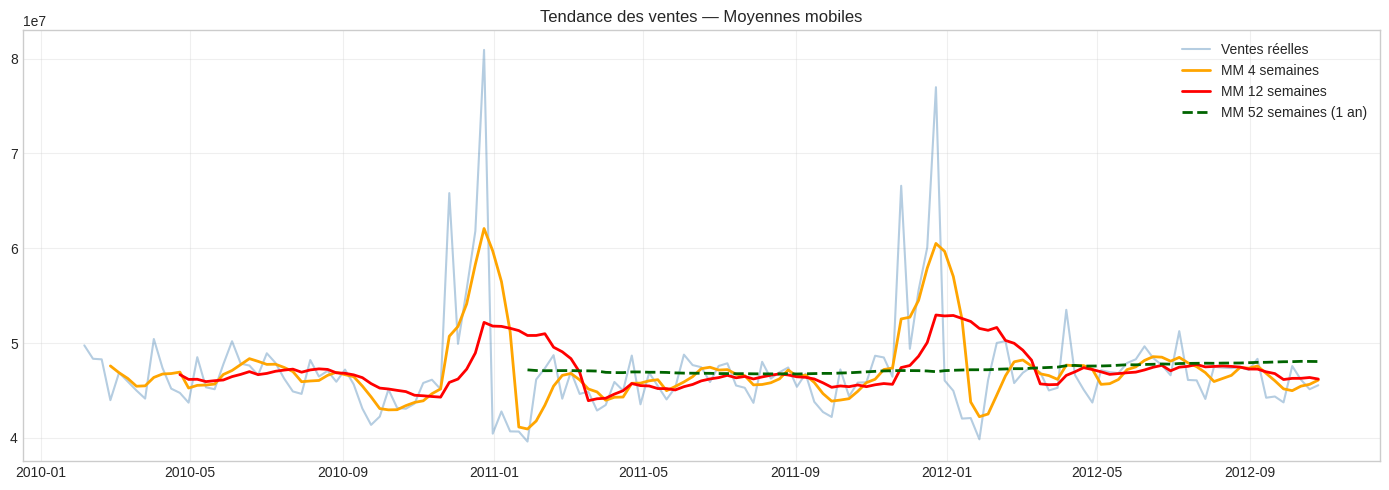

In [14]:
# ====================================================
# 📉 MOYENNE MOBILE — VISUALISATION DE LA TENDANCE
# ====================================================

# La moyenne mobile lisse les fluctuations à court terme
# et révèle la tendance de fond

plt.figure(figsize=(14, 5))

plt.plot(df['Weekly_Sales'], label='Ventes réelles', alpha=0.4, color='steelblue')
plt.plot(df['Weekly_Sales'].rolling(window=4).mean(),  label='MM 4 semaines', linewidth=2, color='orange')
plt.plot(df['Weekly_Sales'].rolling(window=12).mean(), label='MM 12 semaines', linewidth=2, color='red')
plt.plot(df['Weekly_Sales'].rolling(window=52).mean(), label='MM 52 semaines (1 an)', linewidth=2, color='darkgreen', linestyle='--')

plt.title("Tendance des ventes — Moyennes mobiles")
plt.legend()
plt.tight_layout()
plt.show()

# La MM52 (annuelle) montre la tendance à très long terme
# La MM4 reste proche du bruit, utile pour détecter les changements récents

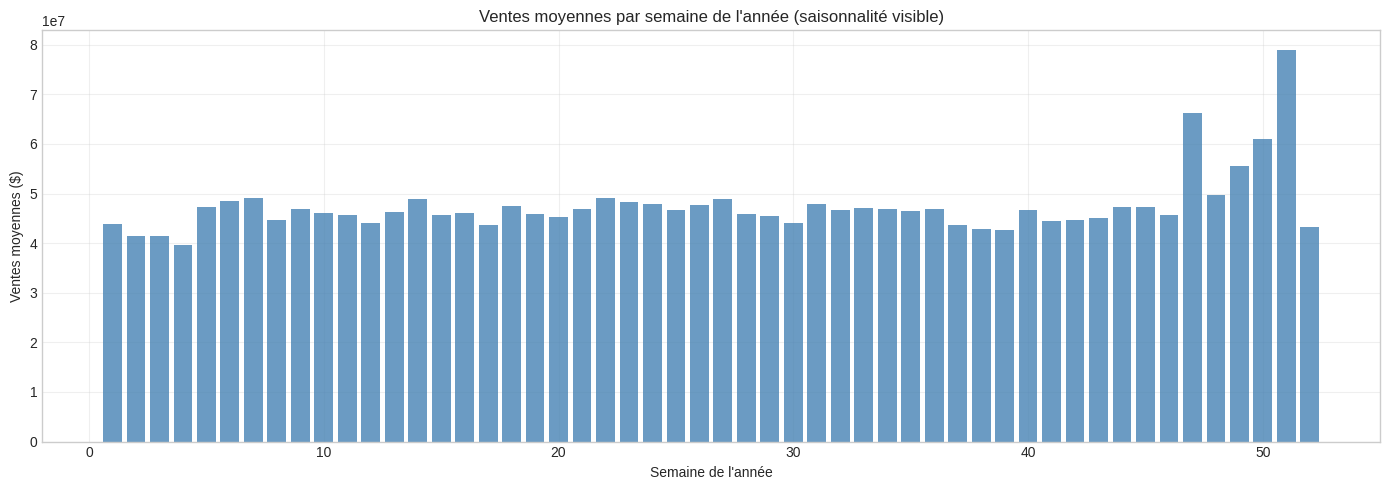

In [15]:
# ====================================================
# 📅 ANALYSE PAR PÉRIODE (Saisonnalité manuelle)
# ====================================================

# On extrait le numéro de semaine pour voir quelles semaines génèrent le plus de ventes
df['Week_of_Year'] = df.index.isocalendar().week.astype(int)

weekly_avg = df.groupby('Week_of_Year')['Weekly_Sales'].mean()

plt.figure(figsize=(14, 5))
plt.bar(weekly_avg.index, weekly_avg.values, color='steelblue', alpha=0.8)
plt.title("Ventes moyennes par semaine de l'année (saisonnalité visible)")
plt.xlabel("Semaine de l'année")
plt.ylabel("Ventes moyennes ($)")
plt.tight_layout()
plt.show()

# On voit clairement les pics en fin d'année (semaines 48-52 = Black Friday + Noël)

df = df.drop(columns=['Week_of_Year'])  # Nettoyage : on retire la colonne temporaire

Corrélations avec Weekly_Sales :
Temperature    -0.159160
Fuel_Price     -0.056722
Unemployment    0.003524
CPI             0.023413
Holiday_Flag    0.172683
Name: Weekly_Sales, dtype: float64


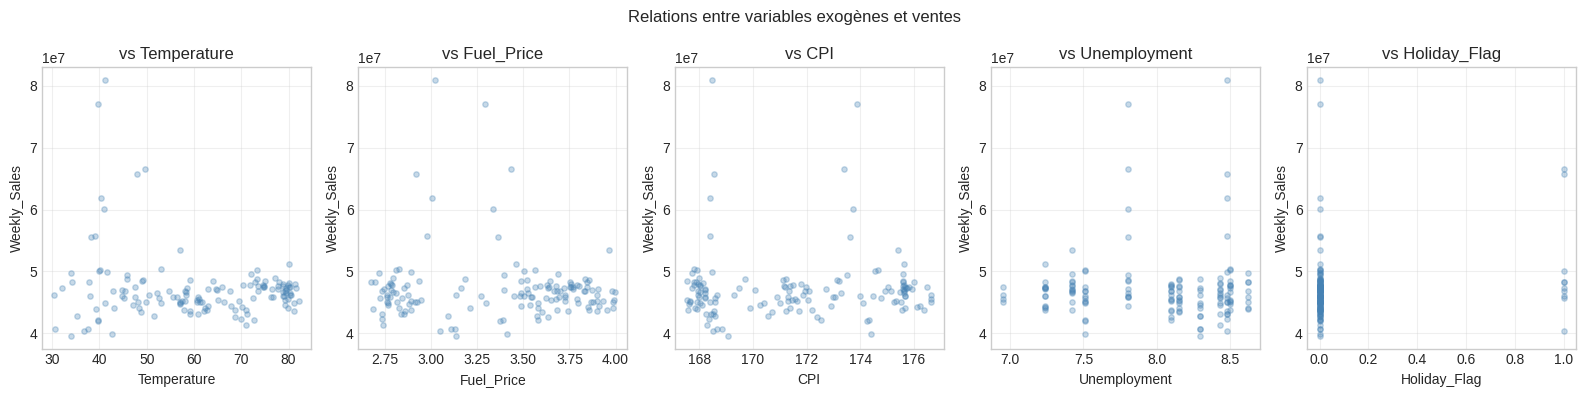

In [16]:
# ====================================================
# 🔗 CORRÉLATION AVEC LES VARIABLES EXOGÈNES
# ====================================================

if exog_cols:
    print("Corrélations avec Weekly_Sales :")
    print(df[['Weekly_Sales'] + exog_cols].corr()['Weekly_Sales'].drop('Weekly_Sales').sort_values())
    
    fig, axes = plt.subplots(1, len(exog_cols), figsize=(16, 4))
    for i, col in enumerate(exog_cols):
        axes[i].scatter(df[col], df['Weekly_Sales'], alpha=0.3, s=15, color='steelblue')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Weekly_Sales')
        axes[i].set_title(f'vs {col}')
    plt.suptitle("Relations entre variables exogènes et ventes")
    plt.tight_layout()
    plt.show()
else:
    print("Pas de variables exogènes disponibles.")

---
## 🔬 5. Décomposition de la série

Décomposition ADDITIVE


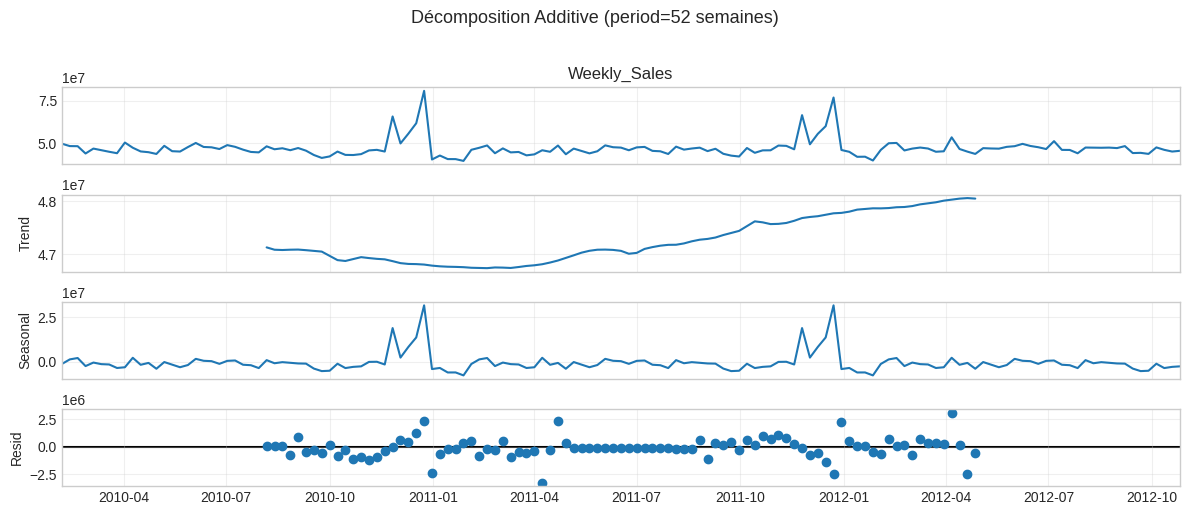

In [17]:
# ====================================================
# 📊 DÉCOMPOSITION ADDITIVE VS MULTIPLICATIVE
# ====================================================

# Additive    → amplitude de la saisonnalité constante dans le temps
# Multiplicative → amplitude de la saisonnalité proportionnelle au niveau des ventes
# 
# Pour choisir, on regarde si la variance augmente avec le niveau
# Ici les ventes Walmart sont assez stables → modèle additif souvent adapté

print("Décomposition ADDITIVE")
decomp_add = seasonal_decompose(df['Weekly_Sales'], model='additive', period=52)
decomp_add.plot()
plt.suptitle("Décomposition Additive (period=52 semaines)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Ce qu'on lit :
# Trend    → tendance à long terme (hausse, baisse, plateau)
# Seasonal → effet répétitif chaque année (pics de fêtes)
# Residual → ce que le modèle n'explique pas = bruit aléatoire

In [18]:
# ====================================================
# 💪 FORCE DE LA SAISONNALITÉ ET DE LA TENDANCE
# ====================================================

# Méthode : mesurer la variance du résidu vs composante
# Si la variance des résidus est petite → la composante est forte

trend_strength = max(0, 1 - np.var(decomp_add.resid.dropna()) / np.var((decomp_add.trend + decomp_add.resid).dropna()))
seasonal_strength = max(0, 1 - np.var(decomp_add.resid.dropna()) / np.var((decomp_add.seasonal + decomp_add.resid).dropna()))

print(f"Force de la tendance    : {trend_strength:.3f} (0 = absente, 1 = très forte)")
print(f"Force de la saisonnalité: {seasonal_strength:.3f} (0 = absente, 1 = très forte)")

Force de la tendance    : 0.248 (0 = absente, 1 = très forte)
Force de la saisonnalité: 0.980 (0 = absente, 1 = très forte)


---
## 📐 6. Tests de Stationnarité (ADF + KPSS)

In [19]:
# ====================================================
# 🧪 TEST ADF (Augmented Dickey-Fuller)
# ====================================================

# H₀ (hypothèse nulle) : la série a une racine unitaire → NON stationnaire
# Si p-value < 0.05 → on rejette H₀ → la série EST stationnaire

def adf_test(series, name='Série'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{'='*50}")
    print(f"  Test ADF — {name}")
    print(f"{'='*50}")
    print(f"  Statistique ADF : {result[0]:.4f}")
    print(f"  p-value         : {result[1]:.4g}")
    print(f"  Valeurs critiques :")
    for key, val in result[4].items():
        print(f"    {key}: {val:.4f}")
    if result[1] < 0.05:
        print(f"  ✅ Conclusion : STATIONNAIRE (p < 0.05)")
    else:
        print(f"  ❌ Conclusion : NON STATIONNAIRE (p ≥ 0.05)")

adf_test(df['Weekly_Sales'], 'Weekly_Sales')


  Test ADF — Weekly_Sales
  Statistique ADF : -5.9083
  p-value         : 2.676e-07
  Valeurs critiques :
    1%: -3.4786
    5%: -2.8827
    10%: -2.5781
  ✅ Conclusion : STATIONNAIRE (p < 0.05)


In [20]:
# ====================================================
# 🧪 TEST KPSS (Kwiatkowski–Phillips–Schmidt–Shin)
# ====================================================

# H₀ (hypothèse nulle) : la série EST stationnaire
# Si p-value < 0.05 → on rejette H₀ → la série est NON stationnaire
# 
# KPSS et ADF sont complémentaires — ils se confirment ou se contredisent
#  ADF stationnaire + KPSS stationnaire → ✅ définitivement stationnaire
#  ADF non-stationnaire + KPSS non-stationnaire → ❌ différenciation nécessaire
#  Résultats contradictoires → borderline, différenciation prudente

def kpss_test(series, name='Série'):
    stat, p_value, lags, crit = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\n{'='*50}")
    print(f"  Test KPSS — {name}")
    print(f"{'='*50}")
    print(f"  Statistique KPSS : {stat:.4f}")
    print(f"  p-value          : {p_value:.4f}")
    print(f"  Valeurs critiques : {crit}")
    if p_value > 0.05:
        print(f"  ✅ Conclusion : STATIONNAIRE (p > 0.05, on ne rejette pas H₀)")
    else:
        print(f"  ❌ Conclusion : NON STATIONNAIRE (p ≤ 0.05, on rejette H₀)")

kpss_test(df['Weekly_Sales'], 'Weekly_Sales')


  Test KPSS — Weekly_Sales
  Statistique KPSS : 0.0489
  p-value          : 0.1000
  Valeurs critiques : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  ✅ Conclusion : STATIONNAIRE (p > 0.05, on ne rejette pas H₀)


In [21]:
# ====================================================
# 🔁 DÉCISION SUR LA DIFFÉRENCIATION (paramètre d)
# ====================================================

# Règle de décision combinée ADF + KPSS (au lieu de fixer d=0 "à la main")
adf_p  = adfuller(df['Weekly_Sales'].dropna(), autolag='AIC')[1]
kpss_p = kpss(df['Weekly_Sales'].dropna(), regression='c', nlags='auto')[1]

is_stationary = (adf_p < 0.05) and (kpss_p > 0.05)
d_choice = 0 if is_stationary else 1

print(f"ADF  p-value : {adf_p:.2e}  (H₀ = non stationnaire)")
print(f"KPSS p-value : {kpss_p:.4f}  (H₀ = stationnaire)")
print(f"➡️  Décision : {'série STATIONNAIRE → d = 0' if is_stationary else 'série NON stationnaire → d = 1'}")

# Pour information : la série différenciée (d=1) est évidemment stationnaire aussi
df_diff = df['Weekly_Sales'].diff().dropna()
adf_test(df_diff, 'Weekly_Sales différenciée (d=1)')

# Remarque méthodologique : on n'applique PAS de différenciation saisonnière (D=0).
# Avec seulement ~2,7 ans de données (143 semaines), un D=1 avec m=52 ferait perdre
# 52 observations sur 114 en entraînement — trop coûteux. La saisonnalité est captée
# par la composante AR saisonnière (P) à la place.

ADF  p-value : 2.68e-07  (H₀ = non stationnaire)
KPSS p-value : 0.1000  (H₀ = stationnaire)
➡️  Décision : série STATIONNAIRE → d = 0

  Test ADF — Weekly_Sales différenciée (d=1)
  Statistique ADF : -6.6995
  p-value         : 3.923e-09
  Valeurs critiques :
    1%: -3.4801
    5%: -2.8834
    10%: -2.5784
  ✅ Conclusion : STATIONNAIRE (p < 0.05)


---
## 📉 7. Analyse ACF / PACF

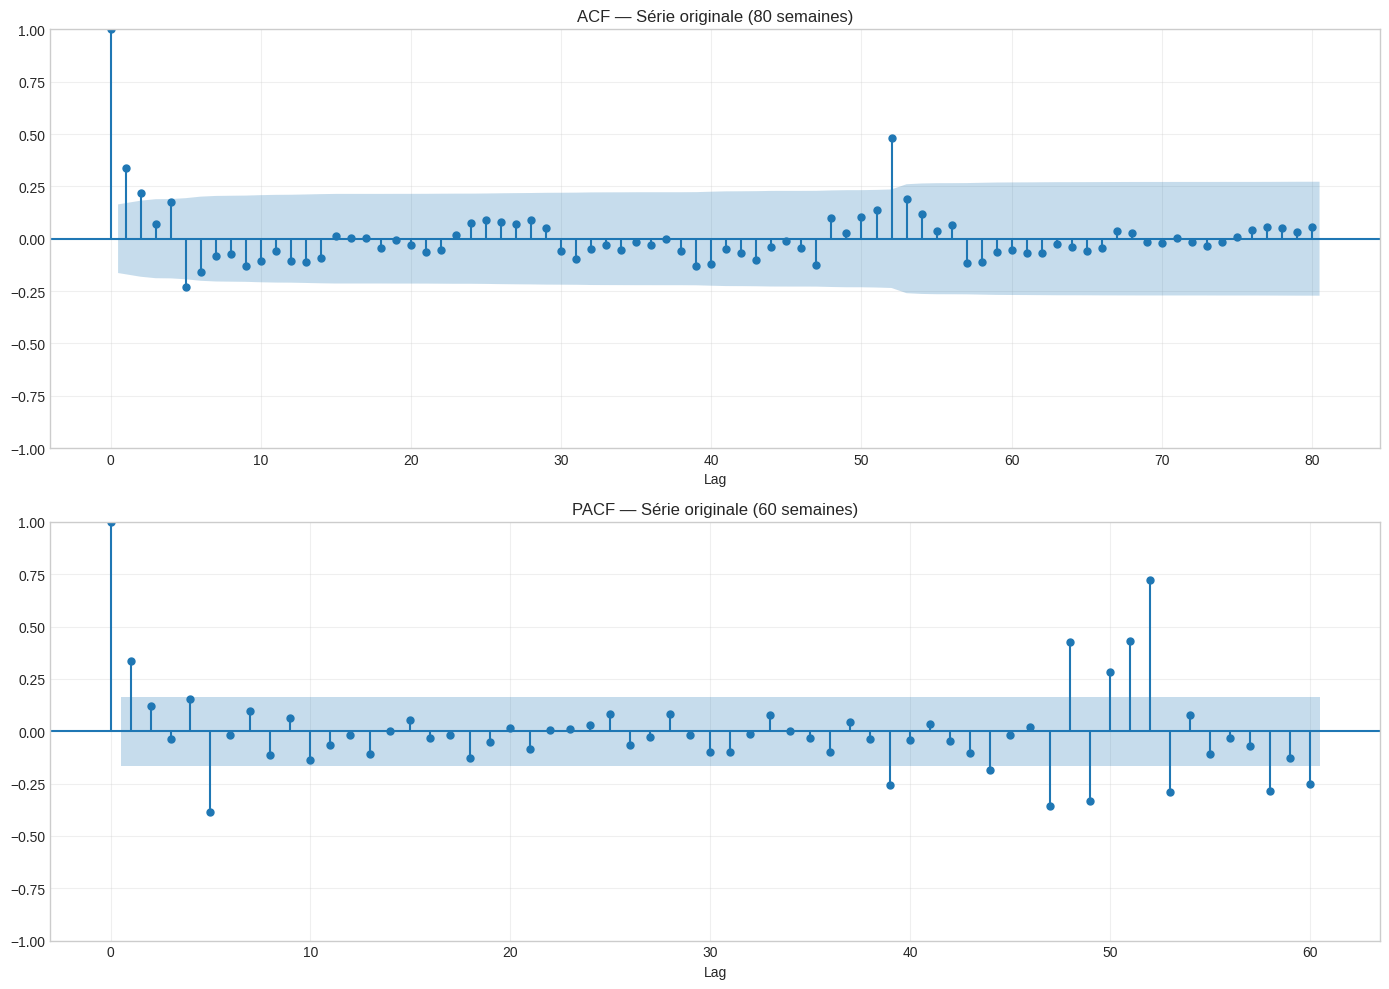

In [22]:
# ====================================================
# 📉 ACF / PACF
# ====================================================

# ACF (Autocorrelation Function) mesure la corrélation entre
# la série et ses valeurs décalées (lags)
#
# Comment lire :
#   - Décroissance lente et progressive → forte composante AR
#   - Coupe brusquement à lag q         → ordre MA = q
#   - Pic à lag 52                      → saisonnalité annuelle confirmée
#
# ⚠️ statsmodels impose lags < 50 % de la taille de l'échantillon pour la PACF
#    (143 semaines → max 71). On prend 60 pour la PACF et 80 pour l'ACF.

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(df['Weekly_Sales'], lags=80, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF — Série originale (80 semaines)")
axes[0].set_xlabel("Lag")

plot_pacf(df['Weekly_Sales'], lags=60, ax=axes[1], alpha=0.05, method='ols')
axes[1].set_title("PACF — Série originale (60 semaines)")
axes[1].set_xlabel("Lag")

plt.tight_layout()
plt.show()

# Lecture : le pic au lag 52 confirme la saisonnalité annuelle → m = 52

---
## 📏 8. Modèle Baseline (référence)

In [23]:
# ====================================================
# 🔀 SPLIT TRAIN / TEST (avant de faire quoi que ce soit)
# ====================================================

# Le split DOIT être chronologique (jamais aléatoire pour une ST)
# On garde les 20% derniers comme test set

train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test  = df.iloc[train_size:]

print(f"Train : {train.index[0]} → {train.index[-1]} ({len(train)} semaines)")
print(f"Test  : {test.index[0]}  → {test.index[-1]}  ({len(test)} semaines)")

Train : 2010-02-05 00:00:00 → 2012-04-06 00:00:00 (114 semaines)
Test  : 2012-04-13 00:00:00  → 2012-10-26 00:00:00  (29 semaines)


In [24]:
# ====================================================
# 🧱 BASELINE 1 : NAÏVE (dernière valeur connue)
# ====================================================

# Le modèle le plus simple possible : "la semaine prochaine = cette semaine"
# C'est notre plancher minimum : tout modèle doit faire mieux que ça

naive_pred = pd.Series(
    [train['Weekly_Sales'].iloc[-1]] * len(test),
    index=test.index
)

mae_naive  = mean_absolute_error(test['Weekly_Sales'], naive_pred)
rmse_naive = np.sqrt(mean_squared_error(test['Weekly_Sales'], naive_pred))
mape_naive = np.mean(np.abs((test['Weekly_Sales'] - naive_pred) / (test['Weekly_Sales'] + 1e-10))) * 100

print("BASELINE — Modèle Naïf (dernière valeur)")
print(f"  MAE  : {mae_naive:>15,.0f}")
print(f"  RMSE : {rmse_naive:>15,.0f}")
print(f"  MAPE : {mape_naive:>15.2f}%")

BASELINE — Modèle Naïf (dernière valeur)
  MAE  :       6,807,045
  RMSE :       7,023,631
  MAPE :           14.73%


In [25]:
# ====================================================
# 🧱 BASELINE 2 : NAÏVE SAISONNIÈRE (même semaine, année N-1)
# ====================================================

# Plus intelligente : "la semaine prochaine = la même semaine l'année dernière"
# Capture la saisonnalité sans aucun modèle statistique
#
# 🔧 Correction : on décale la série COMPLÈTE de +52 semaines (shift(52)),
#    donc la valeur prédite à la date t est celle observée en t-52.
#    (shift(-52) sur le train donnait des NaN remplacés par la moyenne → baseline faussée)
#    Aucune fuite de données : le test fait 29 semaines < 52, donc t-52 est toujours dans le train.

assert len(test) <= 52, "Le test dépasse 52 semaines : la baseline saisonnière utiliserait le test"

seasonal_naive_pred = df['Weekly_Sales'].shift(52).reindex(test.index)
assert seasonal_naive_pred.notna().all()

mae_snv  = mean_absolute_error(test['Weekly_Sales'], seasonal_naive_pred)
rmse_snv = np.sqrt(mean_squared_error(test['Weekly_Sales'], seasonal_naive_pred))
mape_snv = np.mean(np.abs((test['Weekly_Sales'] - seasonal_naive_pred) / (test['Weekly_Sales'] + 1e-10))) * 100

print("BASELINE — Modèle Naïf Saisonnier (lag=52)")
print(f"  MAE  : {mae_snv:>15,.0f}")
print(f"  RMSE : {rmse_snv:>15,.0f}")
print(f"  MAPE : {mape_snv:>15.2f}%")

BASELINE — Modèle Naïf Saisonnier (lag=52)
  MAE  :       1,247,205
  RMSE :       1,562,916
  MAPE :            2.65%


---
## 🤖 9. Sélection automatique des paramètres (auto_arima)

In [26]:
# ====================================================
# 🔍 AUTO_ARIMA — RECHERCHE DES MEILLEURS PARAMÈTRES
# ====================================================

# auto_arima teste différentes combinaisons de paramètres
# et sélectionne celle avec le meilleur AIC (compromis fit / complexité)
#
# Paramètres SARIMA(p,d,q)(P,D,Q,m) :
#   p, q   → ordre AR et MA non-saisonniers
#   d      → degré de différenciation (décidé par ADF + KPSS plus haut)
#   P, Q   → ordre AR et MA saisonniers
#   D      → différenciation saisonnière (0, voir remarque section 6)
#   m      → période de saisonnalité (52 pour hebdomadaire annuel)
#
# 🔧 Corrections : pmdarima 2.x utilise X= (et non exogenous=) ;
#    max_P / max_Q = 1 car un P=2 avec m=52 demanderait 104 lags pour seulement 114 obs d'entraînement.

auto_model = auto_arima(
    train['Weekly_Sales'],
    X=train[exog_cols],
    seasonal=True,
    m=52,
    max_p=3, max_q=3,
    max_P=1, max_Q=1,
    d=d_choice,
    D=0,
    information_criterion='aic',
    trace=True,    # affiche tous les modèles testés
    stepwise=True, # recherche intelligente (pas force brute)
    error_action='ignore',
    suppress_warnings=True
)

print("\n" + "="*50)
print("MODÈLE SÉLECTIONNÉ PAR AUTO_ARIMA")
print("="*50)
print(f"Ordre non-saisonnier : {auto_model.order}")
print(f"Ordre saisonnier     : {auto_model.seasonal_order}")

Performing stepwise search to minimize aic


 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=3840.481, Time=2.08 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3889.070, Time=0.02 sec


 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=inf, Time=0.50 sec


 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=3855.471, Time=0.41 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=4313.997, Time=0.01 sec


 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=3846.901, Time=1.43 sec


...

 ARIMA(2,0,3)(1,0,0)[52]             : AIC=inf, Time=1.75 sec


 ARIMA(1,0,1)(1,0,0)[52]             : AIC=3843.598, Time=0.59 sec


 ARIMA(1,0,3)(1,0,0)[52]             : AIC=3851.558, Time=1.43 sec


 ARIMA(3,0,1)(1,0,0)[52]             : AIC=3844.946, Time=1.23 sec


 ARIMA(3,0,3)(1,0,0)[52]             : AIC=inf, Time=2.24 sec

Best model:  ARIMA(2,0,2)(1,0,0)[52]          
Total fit time: 31.998 seconds

MODÈLE SÉLECTIONNÉ PAR AUTO_ARIMA
Ordre non-saisonnier : (2, 0, 2)
Ordre saisonnier     : (1, 0, 0, 52)


---
## 🏗️ 10. Entraînement SARIMAX

In [27]:
# ====================================================
# 🏗️ ENTRAÎNEMENT DU MODÈLE SARIMAX
# ====================================================

# On reprend les paramètres trouvés par auto_arima
# et on entraîne avec statsmodels pour accéder aux diagnostics complets

best_order          = auto_model.order          # (p, d, q)
best_seasonal_order = auto_model.seasonal_order  # (P, D, Q, m)

print(f"Entraînement SARIMAX{best_order} × {best_seasonal_order}...")

model = SARIMAX(
    train['Weekly_Sales'],
    exog=train[exog_cols] if exog_cols else None,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

print("\n✅ Modèle entraîné")
print(f"AIC : {results.aic:.2f}")
print(f"BIC : {results.bic:.2f}")
print("\n" + results.summary().as_text())

Entraînement SARIMAX(2, 0, 2) × (1, 0, 0, 52)...



✅ Modèle entraîné
AIC : 1995.96
BIC : 2019.00

                                      SARIMAX Results                                      
Dep. Variable:                        Weekly_Sales   No. Observations:                  114
Model:             SARIMAX(2, 0, 2)x(1, 0, [], 52)   Log Likelihood                -986.981
Date:                             Tue, 06 Oct 2026   AIC                           1995.961
Time:                                     09:44:12   BIC                           2018.999
Sample:                                 02-05-2010   HQIC                          2004.973
                                      - 04-06-2012                                         
Covariance Type:                               opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Temperature  -4.899e+04   7.68e+05     -0.064      0.9

---
## 🔍 11. Diagnostic des Résidus

Résidus conservés : 62 (52 premières semaines d'initialisation écartées)


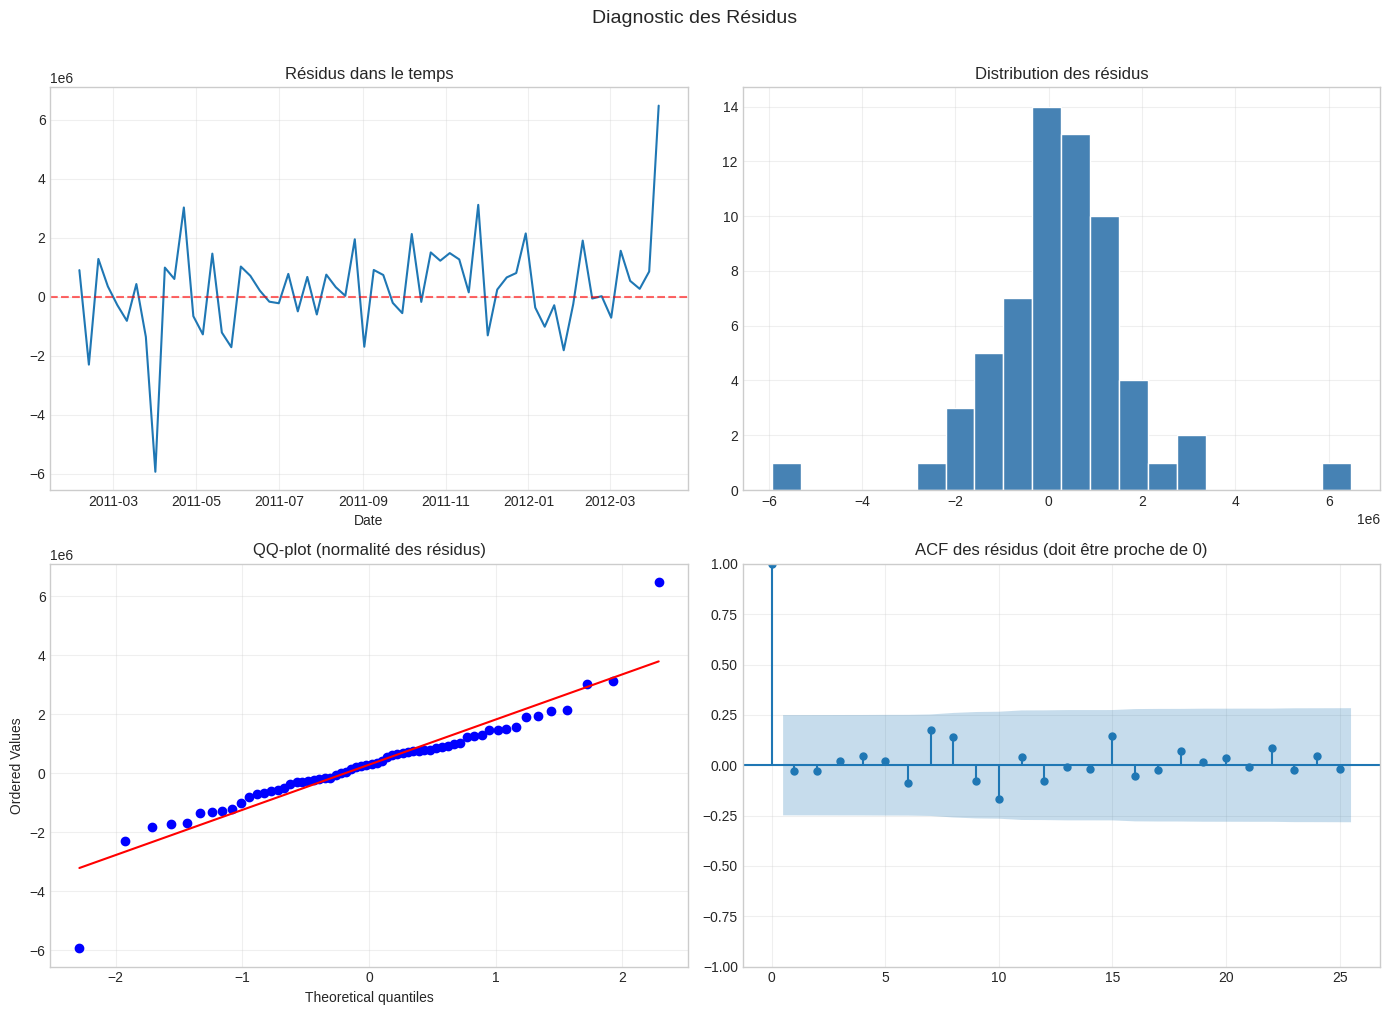

In [28]:
# ====================================================
# 🔍 DIAGNOSTIC COMPLET DES RÉSIDUS
# ====================================================

# Un bon modèle = résidus qui ressemblent à un bruit blanc (aléatoire)
# On vérifie : normalité + absence d'autocorrélation + variance constante
#
# 🔧 Les 52 premiers résidus d'un SARIMA saisonnier (m=52) sont artificiellement grands :
#    le filtre de Kalman n'a pas encore "vu" une saison complète (initialisation).
#    On les écarte pour ne pas fausser les diagnostics.

residuals = results.resid.iloc[52:]
print(f"Résidus conservés : {len(residuals)} (52 premières semaines d'initialisation écartées)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Résidus dans le temps
axes[0, 0].plot(residuals)
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.6)
axes[0, 0].set_title("Résidus dans le temps")
axes[0, 0].set_xlabel("Date")

# 2. Distribution des résidus
residuals.hist(bins=20, ax=axes[0, 1], color='steelblue', edgecolor='white')
axes[0, 1].set_title("Distribution des résidus")

# 3. QQ-plot (normalité)
stats.probplot(residuals, plot=axes[1, 0])
axes[1, 0].set_title("QQ-plot (normalité des résidus)")

# 4. ACF des résidus
plot_acf(residuals.dropna(), lags=25, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title("ACF des résidus (doit être proche de 0)")

plt.suptitle("Diagnostic des Résidus", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# ====================================================
# 🧪 TESTS STATISTIQUES SUR LES RÉSIDUS
# ====================================================

# --- Test de Ljung-Box (autocorrélation des résidus) ---
# H₀ : pas d'autocorrélation dans les résidus
# Si p > 0.05 → on ne rejette pas H₀ → résidus bien bruit blanc ✅

lb_test = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
print("Test de Ljung-Box :")
print(lb_test)
print()

# --- Test ARCH (hétéroscédasticité) ---
# H₀ : variance des résidus est constante (homoscédastique)
# Si p > 0.05 → variance stable ✅

arch_stat, arch_p, _, _ = het_arch(residuals.dropna(), nlags=10)
print(f"Test ARCH (variance constante) :")
print(f"  Statistique : {arch_stat:.4f}")
print(f"  p-value     : {arch_p:.4f}")
if arch_p > 0.05:
    print("  ✅ Variance constante (homoscédastique)")
else:
    print("  ⚠️ Hétéroscédasticité détectée (variance non constante)")

# --- Test de normalité (Jarque-Bera) ---
jb_stat, jb_p = stats.jarque_bera(residuals.dropna())
print(f"\nTest Jarque-Bera (normalité) :")
print(f"  Statistique : {jb_stat:.4f}")
print(f"  p-value     : {jb_p:.4f}")
if jb_p > 0.05:
    print("  ✅ Résidus normalement distribués")
else:
    print("  ⚠️ Résidus non normaux (tolérable sur petite série, à surveiller)")

Test de Ljung-Box :
      lb_stat  lb_pvalue
10   7.132971   0.712835
20  10.537382   0.957349

Test ARCH (variance constante) :
  Statistique : 2.0746
  p-value     : 0.9957
  ✅ Variance constante (homoscédastique)

Test Jarque-Bera (normalité) :
  Statistique : 74.2277
  p-value     : 0.0000
  ⚠️ Résidus non normaux (tolérable sur petite série, à surveiller)


---
## 📊 12. Évaluation sur le test set

In [30]:
# ====================================================
# 📊 PRÉDICTIONS SUR LE TEST SET
# ====================================================

test_exog = test[exog_cols].values if exog_cols else None

forecast_test = results.get_forecast(
    steps=len(test),
    exog=test_exog
)

pred_test = forecast_test.predicted_mean
conf_int  = forecast_test.conf_int()

# Calcul des métriques SARIMA
mae_sarima  = mean_absolute_error(test['Weekly_Sales'], pred_test)
rmse_sarima = np.sqrt(mean_squared_error(test['Weekly_Sales'], pred_test))
mape_sarima = np.mean(np.abs((test['Weekly_Sales'] - pred_test) / (test['Weekly_Sales'] + 1e-10))) * 100

# ====================================================
# 📋 TABLEAU COMPARATIF SARIMA vs BASELINES
# ====================================================

print("=" * 65)
print(f"{'Modèle':<30} {'MAE':>10} {'RMSE':>15} {'MAPE':>8}")
print("=" * 65)
print(f"{'Baseline Naïf':<30} {mae_naive:>10,.0f} {rmse_naive:>15,.0f} {mape_naive:>7.2f}%")
print(f"{'Baseline Naïf Saisonnier':<30} {mae_snv:>10,.0f} {rmse_snv:>15,.0f} {mape_snv:>7.2f}%")
print(f"{'SARIMAX (notre modèle)':<30} {mae_sarima:>10,.0f} {rmse_sarima:>15,.0f} {mape_sarima:>7.2f}%")
print("=" * 65)

# Amélioration par rapport à la meilleure baseline
best_baseline_mape = min(mape_naive, mape_snv)
gain = best_baseline_mape - mape_sarima
print(f"\n📈 Gain vs meilleure baseline : {gain:.2f} points de MAPE "
      f"({gain / best_baseline_mape * 100:.0f}% d'erreur en moins)")
if gain > 0:
    print("✅ Le modèle SARIMA surpasse les baselines")
else:
    print("⚠️ Le modèle ne bat pas les baselines — à investiguer")

# ⚠️ Note de rigueur : sur le test set, on fournit au modèle les VRAIES valeurs des exogènes
# (température, carburant, CPI, chômage, jours fériés). En production il faut les prévoir
# ou les connaître à l'avance (le calendrier des jours fériés l'est ; la météo non).

Modèle                                MAE            RMSE     MAPE
Baseline Naïf                   6,807,045       7,023,631   14.73%
Baseline Naïf Saisonnier        1,247,205       1,562,916    2.65%
SARIMAX (notre modèle)            990,574       1,392,173    2.12%

📈 Gain vs meilleure baseline : 0.53 points de MAPE (20% d'erreur en moins)
✅ Le modèle SARIMA surpasse les baselines


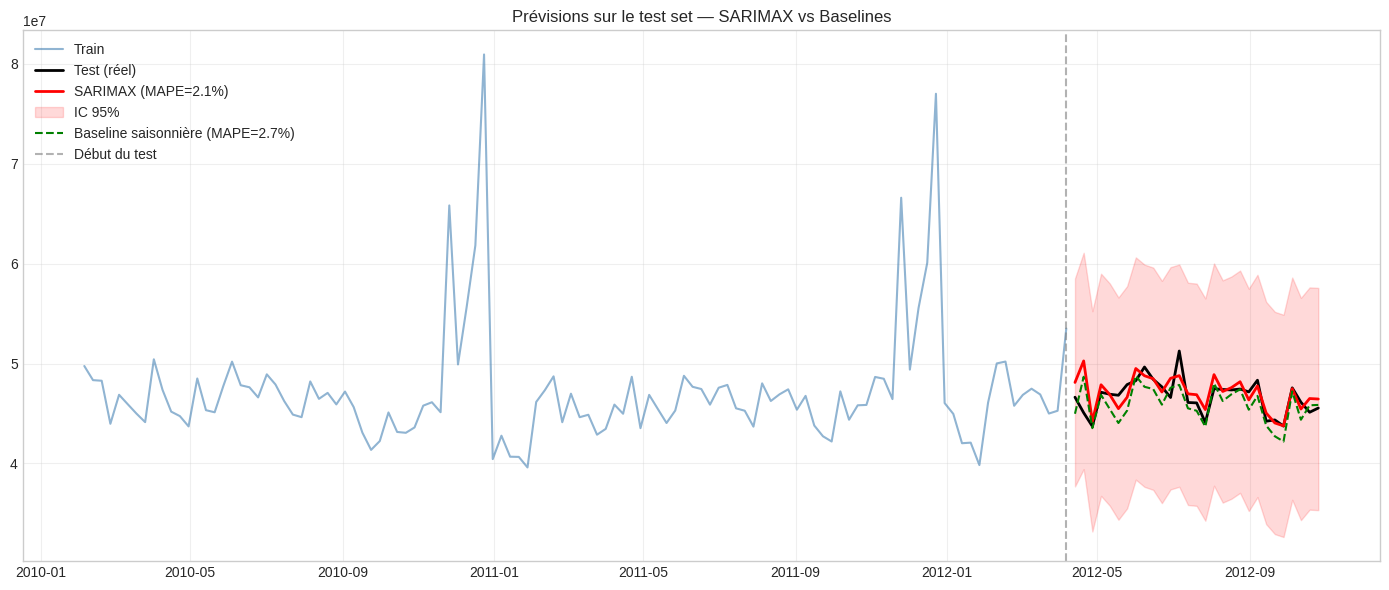

In [31]:
# ====================================================
# 📈 VISUALISATION : RÉEL vs PRÉDIT vs BASELINES
# ====================================================

plt.figure(figsize=(14, 6))

# Historique train
plt.plot(train['Weekly_Sales'], label='Train', color='steelblue', alpha=0.6)

# Réel test
plt.plot(test['Weekly_Sales'], label='Test (réel)', color='black', linewidth=2)

# Prédiction SARIMA
plt.plot(pred_test, label=f'SARIMAX (MAPE={mape_sarima:.1f}%)', color='red', linewidth=2)

# Intervalle de confiance
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 alpha=0.15, color='red', label='IC 95%')

# Baseline naïve saisonnière
plt.plot(seasonal_naive_pred, label=f'Baseline saisonnière (MAPE={mape_snv:.1f}%)',
         color='green', linewidth=1.5, linestyle='--')

plt.axvline(train.index[-1], color='gray', linestyle='--', alpha=0.6, label='Début du test')
plt.title("Prévisions sur le test set — SARIMAX vs Baselines")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

---
## 🔄 13. Cross-Validation Temporelle (walk-forward)

Une seule évaluation train/test peut être trompeuse (bonne ou mauvaise chance).  
On utilise un **walk-forward à origine glissante** : on entraîne sur le passé, on prédit les **13 semaines** suivantes (1 trimestre), puis on avance.

> 🔧 Avec `m = 52`, un pli d'entraînement de moins de 52 semaines n'a aucun sens (une saison complète est nécessaire).  
> On utilise donc `TimeSeriesSplit(n_splits=4, test_size=13)` → entraînements de 91 à 130 semaines.

In [32]:
# ====================================================
# 🔄 CROSS-VALIDATION TEMPORELLE (walk-forward, 4 plis × 13 semaines)
# ====================================================

tscv = TimeSeriesSplit(n_splits=4, test_size=13)

cv_scores, cv_scores_snv, cv_rows = [], [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    cv_train = df.iloc[train_idx]
    cv_test  = df.iloc[test_idx]

    try:
        cv_model = SARIMAX(
            cv_train['Weekly_Sales'],
            exog=cv_train[exog_cols],
            order=best_order,
            seasonal_order=best_seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        cv_pred = cv_model.get_forecast(steps=len(cv_test), exog=cv_test[exog_cols]).predicted_mean
        cv_snv  = df['Weekly_Sales'].shift(52).reindex(cv_test.index)

        y_true = cv_test['Weekly_Sales']
        mape_cv     = np.mean(np.abs((y_true - cv_pred) / y_true)) * 100
        mape_cv_snv = np.mean(np.abs((y_true - cv_snv)  / y_true)) * 100
        cv_scores.append(mape_cv)
        cv_scores_snv.append(mape_cv_snv)

        cv_rows.append({
            'Pli': fold + 1,
            'Train (sem.)': len(cv_train),
            'Test': f"{cv_test.index[0].date()} → {cv_test.index[-1].date()}",
            'MAPE SARIMAX (%)': round(mape_cv, 2),
            'MAPE Saisonnière (%)': round(mape_cv_snv, 2),
        })
    except Exception as e:
        print(f"Pli {fold+1} — Erreur : {e}")

cv_table = pd.DataFrame(cv_rows).set_index('Pli')
display(cv_table)

if cv_scores:
    print(f"\n{'='*50}")
    print(f"MAPE moyen SARIMAX (CV)     : {np.mean(cv_scores):.2f}%  (±{np.std(cv_scores):.2f})")
    print(f"MAPE moyen Saisonnière (CV) : {np.mean(cv_scores_snv):.2f}%  (±{np.std(cv_scores_snv):.2f})")
    wins = sum(a < b for a, b in zip(cv_scores, cv_scores_snv))
    print(f"→ SARIMAX bat la baseline saisonnière sur {wins}/{len(cv_scores)} plis")
    worst = int(np.argmax(cv_scores))
    print(f"→ Pire pli : n°{worst+1} (MAPE {cv_scores[worst]:.2f}%, entraînement sur {cv_rows[worst]['Train (sem.)']} semaines seulement)")
    print(f"→ Stabilité du modèle : {'✅ Bonne' if np.std(cv_scores) < 2 else '⚠️ Variable'}")

,Train (sem.),Test,MAPE SARIMAX (%),MAPE Saisonnière (%)
Pli,,,,
1,91,2011-11-04 → 2012-01-27,10.54,3.71
2,104,2012-02-03 → 2012-04-27,3.11,4.43
3,117,2012-05-04 → 2012-07-27,2.15,2.96
4,130,2012-08-03 → 2012-10-26,2.01,2.04



MAPE moyen SARIMAX (CV)     : 4.45%  (±3.54)
MAPE moyen Saisonnière (CV) : 3.28%  (±0.89)
→ SARIMAX bat la baseline saisonnière sur 3/4 plis
→ Pire pli : n°1 (MAPE 10.54%, entraînement sur 91 semaines seulement)
→ Stabilité du modèle : ⚠️ Variable


### 🔎 Lecture de la validation croisée

- Le **pli 1** (test = fin novembre → fin janvier, soit la période de Noël) est entraîné sur **91 semaines** : le modèle n'a vu **qu'un seul** pic de fin d'année. L'erreur y est nettement plus forte.
- ⚠️ À l'inverse, le **test set final** (avril → octobre 2012) est une période **calme, sans pic de fin d'année** : l'erreur de 2,1 % y est donc un peu flatteuse. La validation croisée, qui inclut Noël, donne une image plus complète du risque.
- Dès que le modèle a vu **plus d'une saison complète** (plis 2 à 4, ≥ 104 semaines), l'erreur redescend à **≈ 2–3 %**.
- 👉 **Message clé** : la limite de ce modèle n'est pas l'algorithme mais la **profondeur d'historique** (2,7 ans). Plus on accumule de saisons, plus la composante saisonnière devient fiable.

---
## 🔮 14. Forecast Final

In [33]:
# ====================================================
# 🔄 RÉENTRAÎNEMENT SUR 100% DES DONNÉES
# ====================================================

# On réentraîne sur toutes les données disponibles (train + test)
# pour avoir le modèle le plus précis possible pour les prévisions futures

final_exog = df[exog_cols].values if exog_cols else None

final_model = SARIMAX(
    df['Weekly_Sales'],
    exog=final_exog,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(f"✅ Modèle final entraîné sur {len(df)} observations")
print(f"AIC final : {final_model.aic:.2f}")

✅ Modèle final entraîné sur 143 observations
AIC final : 2932.03


In [34]:
# ====================================================
# 🔮 PRÉVISION DES 12 PROCHAINES SEMAINES
# ====================================================

FORECAST_STEPS = 12  # 12 semaines = ~3 mois

# Dates futures (vendredis suivant la dernière observation)
future_index = pd.date_range(df.index[-1] + pd.Timedelta(weeks=1), periods=FORECAST_STEPS, freq='W-FRI')

# --- Construction des variables exogènes futures (plus réaliste qu'une valeur constante) ---
# • Holiday_Flag  : le calendrier des semaines fériées Walmart est CONNU à l'avance.
#                   Thanksgiving = 23/11/2012 et Noël = 28/12/2012 (mêmes événements que
#                   25/11/2011 et 30/12/2011, vérifiés dans les données ci-dessous).
# • Temperature   : on reprend la valeur de la même semaine l'année précédente (saisonnalité météo)
# • Fuel_Price, CPI, Unemployment : variables lentes → dernière valeur connue
future_holidays = pd.to_datetime(['2012-11-23', '2012-12-28'])
print("Semaines fériées de l'an dernier (données) :",
      [d.date() for d in df.index[(df['Holiday_Flag'] == 1) & (df.index.year == 2011) & (df.index.month >= 11)]])

future_exog = pd.DataFrame(index=future_index, columns=exog_cols, dtype=float)
for col in exog_cols:
    if col == 'Holiday_Flag':
        future_exog[col] = future_index.isin(future_holidays).astype(float)
    elif col == 'Temperature':
        future_exog[col] = df['Temperature'].reindex(future_index - pd.Timedelta(weeks=52)).values
    else:
        future_exog[col] = df[col].iloc[-1]

# Prévision
final_forecast = final_model.get_forecast(steps=FORECAST_STEPS, exog=future_exog)
pred_future  = final_forecast.predicted_mean
conf_future  = final_forecast.conf_int()

# Affichage des valeurs prévues
print("\nPrévisions des 12 prochaines semaines :")
print(f"{'Semaine':<14} {'Prévision ($)':>16} {'IC Inf ($)':>16} {'IC Sup ($)':>16}")
print("-" * 66)
for date, pred_val, lb, ub in zip(
    pred_future.index,
    pred_future.values,
    conf_future.iloc[:, 0].values,
    conf_future.iloc[:, 1].values
):
    print(f"{str(date.date()):<14} {pred_val:>16,.0f} {lb:>16,.0f} {ub:>16,.0f}")

print(f"\nTotal prévu sur 12 semaines : {pred_future.sum():,.0f} $")

Semaines fériées de l'an dernier (données) : [datetime.date(2011, 11, 25), datetime.date(2011, 12, 30)]

Prévisions des 12 prochaines semaines :
Semaine           Prévision ($)       IC Inf ($)       IC Sup ($)
------------------------------------------------------------------
2012-11-02           48,532,018       39,199,753       57,864,283
2012-11-09           48,555,600       39,002,579       58,108,621
2012-11-16           46,757,726       37,195,307       56,320,145
2012-11-23           63,541,410       53,968,043       73,114,776
2012-11-30           49,025,158       39,446,360       58,603,957
2012-12-07           54,014,635       44,433,380       63,595,890
2012-12-14           57,541,295       47,958,945       67,123,646
2012-12-21           71,083,548       61,500,708       80,666,387
2012-12-28           46,708,986       37,125,929       56,292,042
2013-01-04           45,333,616       35,750,463       54,916,770
2013-01-11           43,054,045       33,470,849       52,637,

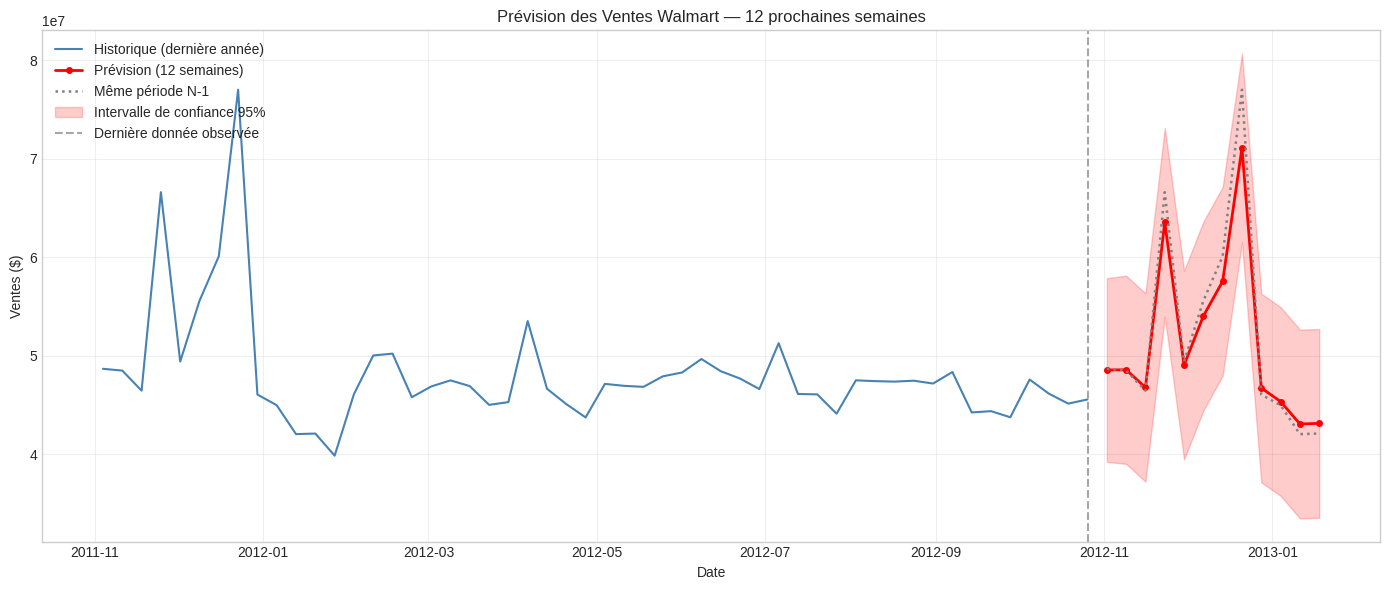

In [35]:
# ====================================================
# 📈 VISUALISATION DU FORECAST FINAL
# ====================================================

plt.figure(figsize=(14, 6))

# Historique (dernières 52 semaines pour la lisibilité)
plt.plot(df['Weekly_Sales'].iloc[-52:], label='Historique (dernière année)', color='steelblue', linewidth=1.5)

# Prévisions futures
plt.plot(pred_future, label='Prévision (12 semaines)', color='red', linewidth=2, marker='o', markersize=4)

# Même période l'année précédente (repère visuel)
last_year = df['Weekly_Sales'].reindex(future_index - pd.Timedelta(weeks=52))
plt.plot(future_index, last_year.values, label='Même période N-1', color='gray', linestyle=':', linewidth=1.8)

# Intervalle de confiance 95%
plt.fill_between(conf_future.index, conf_future.iloc[:, 0], conf_future.iloc[:, 1],
                 alpha=0.2, color='red', label="Intervalle de confiance 95%")

# Ligne de coupure
plt.axvline(df.index[-1], color='gray', linestyle='--', alpha=0.7, label="Dernière donnée observée")

plt.title("Prévision des Ventes Walmart — 12 prochaines semaines")
plt.xlabel("Date")
plt.ylabel("Ventes ($)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

---
## 📝 15. Conclusion & Interprétation Métier

In [36]:
# ====================================================
# 💡 EFFET DES VARIABLES EXOGÈNES (interprétation métier)
# ====================================================

# Les exogènes sont des moyennes sur les 45 magasins ; la cible est la SOMME des 45 magasins.
# Un coefficient se lit donc : "variation des ventes totales hebdo pour +1 unité de la variable".

coef_table = pd.DataFrame({
    'Coefficient': results.params[exog_cols],
    'p-value':     results.pvalues[exog_cols],
})
coef_table['Significatif (5%)'] = np.where(coef_table['p-value'] < 0.05, '✅', '—')
display(coef_table.style.format({'Coefficient': '{:,.0f}', 'p-value': '{:.4f}'}))

hol = coef_table.loc['Holiday_Flag', 'Coefficient']
avg_week = df['Weekly_Sales'].mean()
print(f"\n🎄 Une semaine fériée ajoute en moyenne ≈ {hol:,.0f} $ de ventes totales, "
      f"soit ≈ {hol / avg_week * 100:.1f}% d'une semaine moyenne ({avg_week:,.0f} $).")
print("⚠️ CPI et chômage évoluent lentement et sont corrélés entre eux (multicolinéarité) :")
print("   leurs coefficients individuels sont à interpréter avec prudence.")

,Coefficient,p-value,Significatif (5%)
Temperature,"-48,985",0.9492,—
Fuel_Price,"-1,584,575",0.8593,—
CPI,"311,717",0.5255,—
Unemployment,"224,553",0.9729,—
Holiday_Flag,"3,032,750",0.0087,✅



🎄 Une semaine fériée ajoute en moyenne ≈ 3,032,750 $ de ventes totales, soit ≈ 6.4% d'une semaine moyenne (47,113,419 $).
⚠️ CPI et chômage évoluent lentement et sont corrélés entre eux (multicolinéarité) :
   leurs coefficients individuels sont à interpréter avec prudence.


In [37]:
# ====================================================
# 📋 RÉSUMÉ COMPLET DU PROJET
# ====================================================

print("=" * 60)
print("   RÉSUMÉ DU PROJET — PRÉVISION VENTES WALMART")
print("=" * 60)

print("\n📁 DONNÉES")
print(f"  Période couverte : {df.index[0].date()} → {df.index[-1].date()}")
print(f"  Observations     : {len(df)} semaines (45 magasins agrégés)")
print(f"  Variables exog.  : {exog_cols}")

print("\n🔬 STATIONNARITÉ")
print(f"  ADF p = {adf_p:.2e} | KPSS p = {kpss_p:.2f} → "
      f"{'stationnaire → d=0' if is_stationary else 'non stationnaire → d=1'}")

print("\n🏗️ MODÈLE")
print(f"  Type   : SARIMAX{best_order}×{best_seasonal_order}")
print(f"  AIC    : {final_model.aic:.2f}")

print("\n📊 PERFORMANCES (test set = 29 dernières semaines)")
print(f"  Baseline naïve         → MAPE : {mape_naive:.2f}%")
print(f"  Baseline saisonnière   → MAPE : {mape_snv:.2f}%")
print(f"  SARIMAX (notre modèle) → MAPE : {mape_sarima:.2f}%")
if cv_scores:
    print(f"  Walk-forward (4 plis)  → MAPE SARIMAX {np.mean(cv_scores):.2f}% "
          f"vs saisonnière {np.mean(cv_scores_snv):.2f}%")

print("\n🏁 CONCLUSION MÉTIER")
if mape_sarima < 5:
    print(f"  ✅ Sur le test set : erreur de {mape_sarima:.1f}% → précision adaptée à la planification")
elif mape_sarima < 10:
    print(f"  ✅ Sur le test set : erreur de {mape_sarima:.1f}% → utilisable pour décisions opérationnelles")
else:
    print(f"  ⚠️ Sur le test set : erreur de {mape_sarima:.1f}% → envisager des améliorations")
if cv_scores and max(cv_scores) > 2 * min(cv_scores):
    print(f"  ⚠️ Mais l'erreur varie selon la période (de {min(cv_scores):.1f}% à {max(cv_scores):.1f}% en walk-forward) :")
    print("     la précision dépend du nombre de saisons déjà observées → prudence sur la période de Noël.")
print(f"  ℹ️ Gain du modèle vs baseline saisonnière : {mape_snv - mape_sarima:+.2f} pt de MAPE sur le test set ;")
print("     la baseline saisonnière reste un adversaire redoutable sur une série aussi régulière.")

print("\n🔧 LIMITES & PISTES D'AMÉLIORATION")
print("  1. Seulement ~2,7 ans d'historique : la saison annuelle n'est observée que 2 fois")
print("  2. Exogènes futures supposées (calendrier connu ; météo = N-1 ; autres = dernière valeur)")
print("  3. Modéliser chaque magasin séparément (approche hiérarchique)")
print("  4. Tester des modèles ML (XGBoost / LightGBM avec features lag/rolling)")
print("  5. Intégrer promotions (MarkDown) et événements spéciaux")
print("  6. Réentraîner le modèle chaque mois avec les nouvelles données")

   RÉSUMÉ DU PROJET — PRÉVISION VENTES WALMART

📁 DONNÉES
  Période couverte : 2010-02-05 → 2012-10-26
  Observations     : 143 semaines (45 magasins agrégés)
  Variables exog.  : ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']

🔬 STATIONNARITÉ
  ADF p = 2.68e-07 | KPSS p = 0.10 → stationnaire → d=0

🏗️ MODÈLE
  Type   : SARIMAX(2, 0, 2)×(1, 0, 0, 52)
  AIC    : 2932.03

📊 PERFORMANCES (test set = 29 dernières semaines)
  Baseline naïve         → MAPE : 14.73%
  Baseline saisonnière   → MAPE : 2.65%
  SARIMAX (notre modèle) → MAPE : 2.12%
  Walk-forward (4 plis)  → MAPE SARIMAX 4.45% vs saisonnière 3.28%

🏁 CONCLUSION MÉTIER
  ✅ Sur le test set : erreur de 2.1% → précision adaptée à la planification
  ⚠️ Mais l'erreur varie selon la période (de 2.0% à 10.5% en walk-forward) :
     la précision dépend du nombre de saisons déjà observées → prudence sur la période de Noël.
  ℹ️ Gain du modèle vs baseline saisonnière : +0.53 pt de MAPE sur le test set ;
     la baselin